In [2]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

In [4]:
ruta = "../data/raw/data set modificado.csv"

df = pd.read_csv(
    ruta,
    sep=";",
    engine="python"
)

df.head()

,AÑO,CÓDIGO_DEPARTAMENTO,DEPARTAMENTO,POBLACIÓN_5_16,TASA_MATRICULACIÓN_5_16,COBERTURA_NETA,COBERTURA_NETA_TRANSICIÓN,COBERTURA_NETA_PRIMARIA,COBERTURA_NETA_SECUNDARIA,COBERTURA_NETA_MEDIA,...,REPROBACIÓN,REPROBACIÓN_TRANSICIÓN,REPROBACIÓN_PRIMARIA,REPROBACIÓN_SECUNDARIA,REPROBACIÓN_MEDIA,REPITENCIA,REPITENCIA_TRANSICIÓN,REPITENCIA_PRIMARIA,REPITENCIA_SECUNDARIA,REPITENCIA_MEDIA
0,2023.0,76,Valle del Cauca,842813.0,"78,09%","77,90%","58,61%","74,78%","66,48%","46,35%",...,"8,43%","5,19%","88,92%","12,93%",7%,"9,08%","5,19%","9,01%","11,93%","4,03%"
1,2012.0,27,Chocó,145607.0,"80,97%",NaN,"62,17%","83,24%","41,90%","19,10%",...,"6,03%","1,45%","92,32%",NaN,"4,26%","0,10%","1,45%","0,06%","0,21%","0,11%"
2,NaN,52,Nariño,394574.0,"71,10%","71,13%","38,56%","68,32%","56,56%","29,80%",...,"1,89%","0,04%","97,71%","3,07%","1,92%",NaN,"0,04%","2,36%","3,79%","1,34%"
3,2024.0,63,NaN,82391.0,"90,10%","90,05%","68,48%","88,53%","79,54%","54,69%",...,"6,76%","1,59%","91,19%","11,28%","5,61%","8,03%","1,59%","6,92%","12,08%","4,84%"
4,2023.0,25,Cundinamarca,598065.0,"93,59%","93,32%","62,91%","88,71%","85,25%","56,55%",...,"6,61%","4,09%","92,79%","11,05%","5,40%","8,29%","4,09%","7,09%","12,23%","3,58%"


In [5]:
df_clean = df.copy()

print("Copia creada")

Copia creada


In [6]:
df_clean.isnull().sum()

AÑO                             33
CÓDIGO_DEPARTAMENTO              0
DEPARTAMENTO                    19
POBLACIÓN_5_16                  33
TASA_MATRICULACIÓN_5_16          0
COBERTURA_NETA                  29
COBERTURA_NETA_TRANSICIÓN       29
COBERTURA_NETA_PRIMARIA         29
COBERTURA_NETA_SECUNDARIA        0
COBERTURA_NETA_MEDIA             0
COBERTURA_BRUTA                 29
COBERTURA_BRUTA_TRANSICIÓN      29
COBERTURA_BRUTA_PRIMARIA        29
COBERTURA_BRUTA_SECUNDARIA       0
COBERTURA_BRUTA_MEDIA           36
TAMAÑO_PROMEDIO_DE_GRUPO       240
SEDES_CONECTADAS_A_INTERNET    256
DESERCIÓN                       29
DESERCIÓN_TRANSICIÓN             1
DESERCIÓN_PRIMARIA               0
DESERCIÓN_SECUNDARIA            37
DESERCIÓN_MEDIA                  0
APROBACIÓN                       8
APROBACIÓN_TRANSICIÓN           29
APROBACIÓN_PRIMARIA              0
APROBACIÓN_SECUNDARIA            0
APROBACIÓN_MEDIA                 8
REPROBACIÓN                     29
REPROBACIÓN_TRANSICI

In [7]:
duplicados = df_clean.duplicated().sum()

print(f"Duplicados encontrados: {duplicados}")

Duplicados encontrados: 1


In [8]:
df_clean = df_clean.drop_duplicates()

print("Duplicados eliminados")

Duplicados eliminados


In [9]:
print("Dataset original:", df.shape)
print("Dataset limpio:", df_clean.shape)

Dataset original: (485, 37)
Dataset limpio: (484, 37)


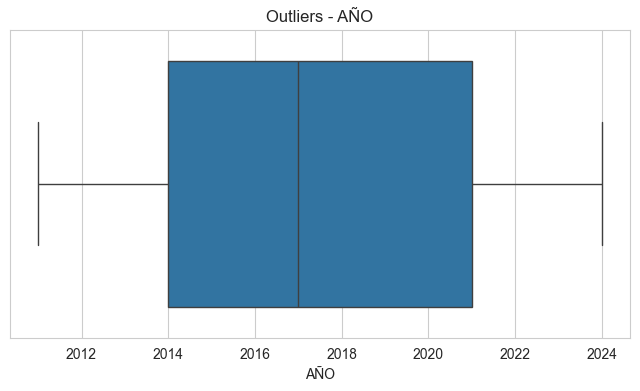

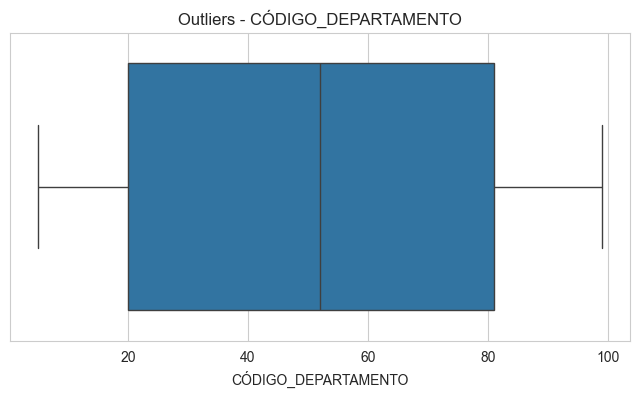

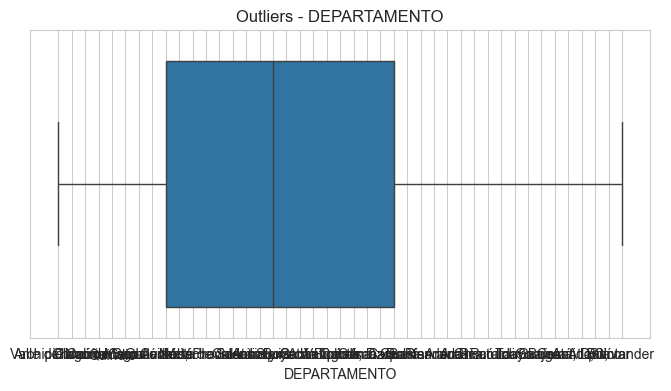

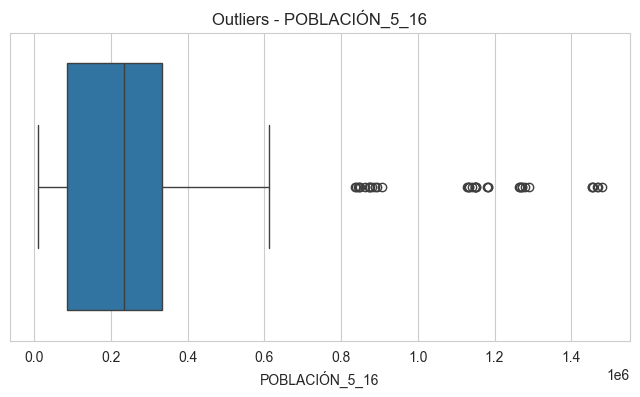

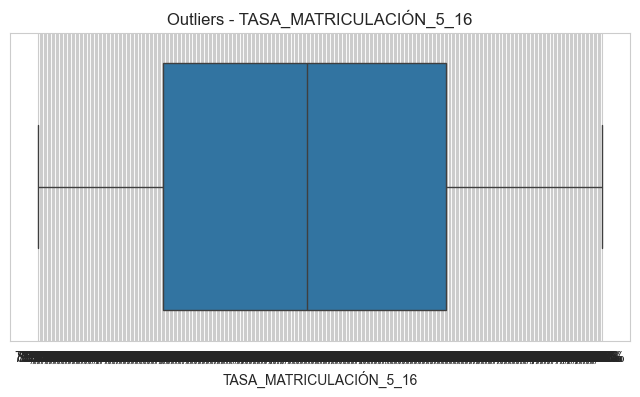

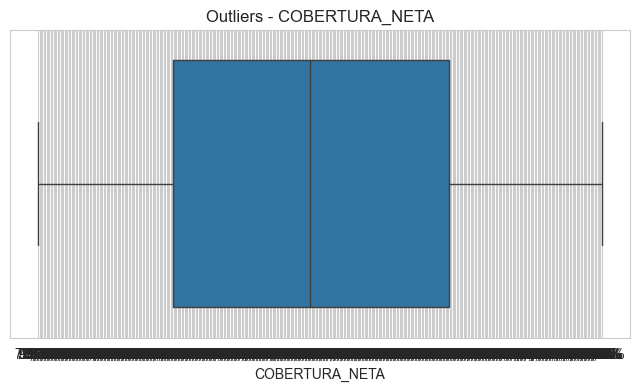

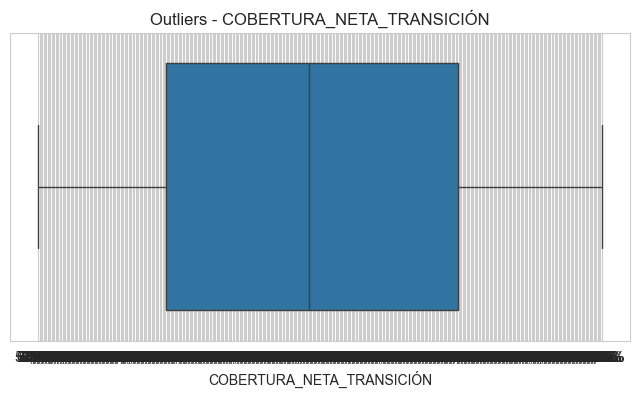

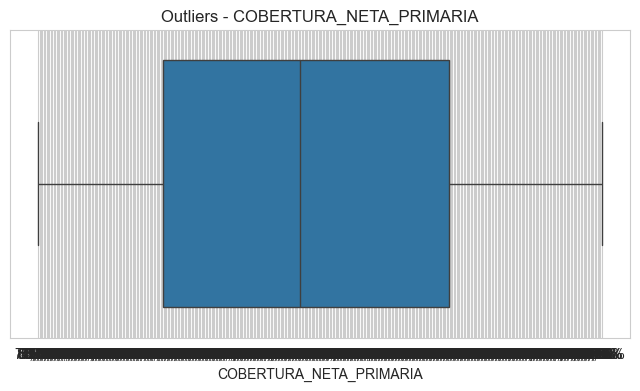

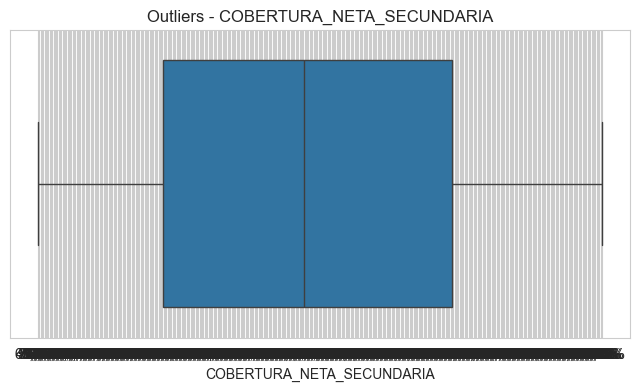

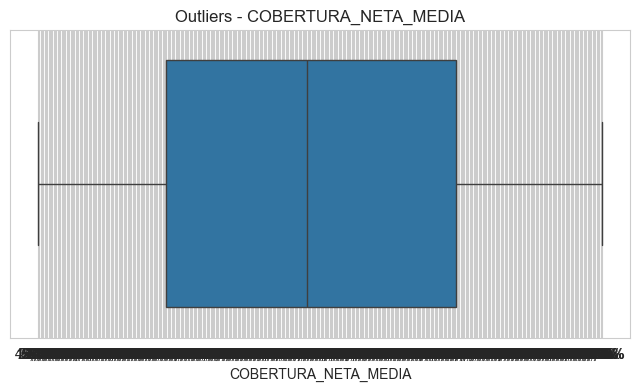

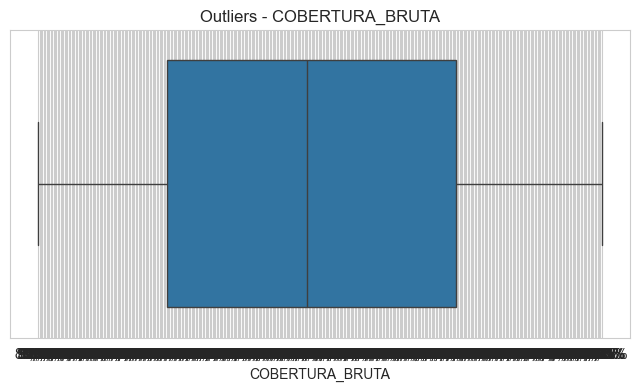

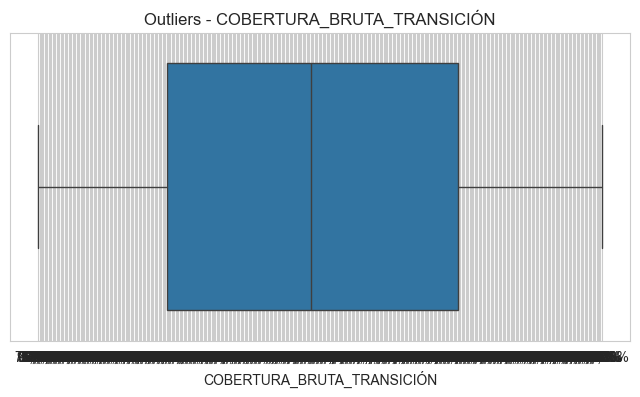

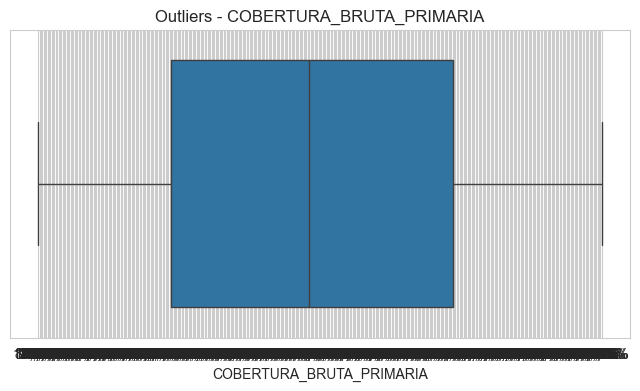

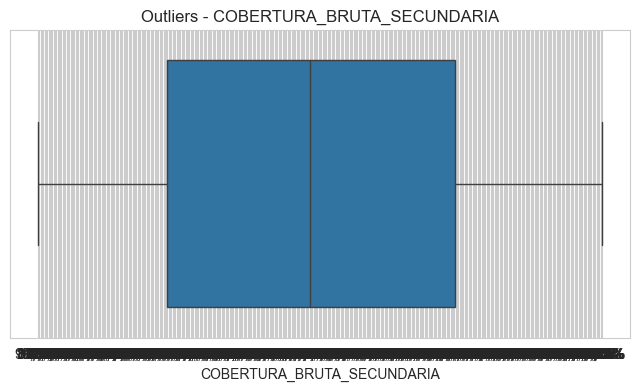

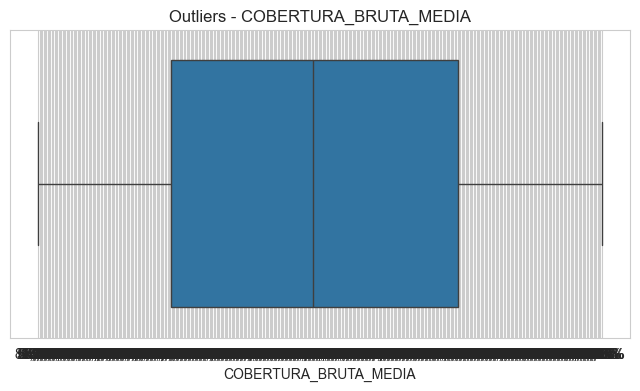

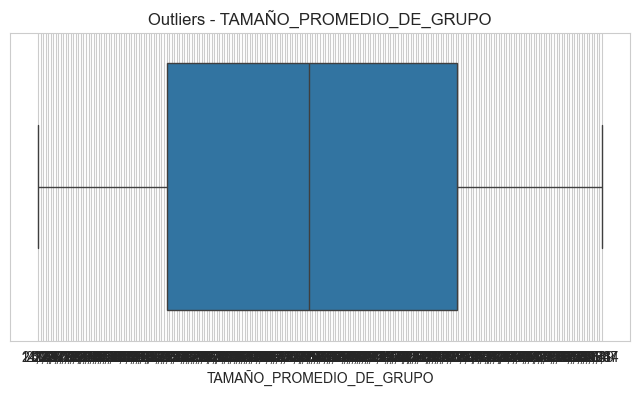

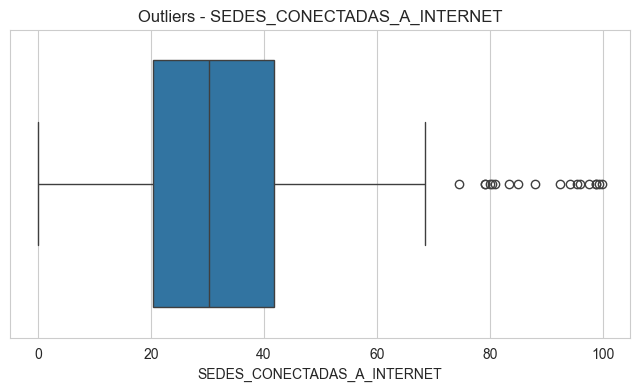

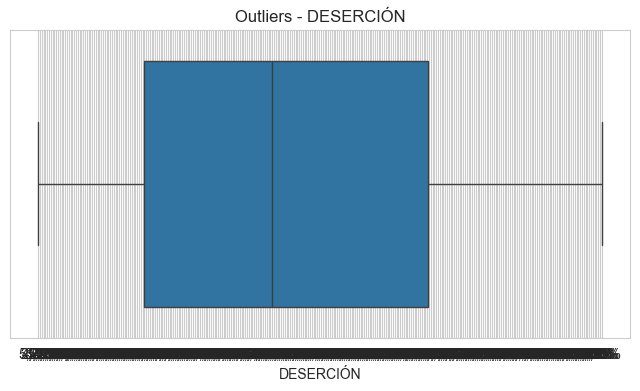

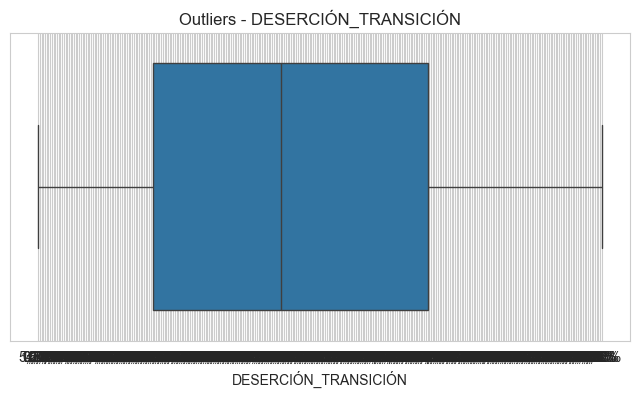

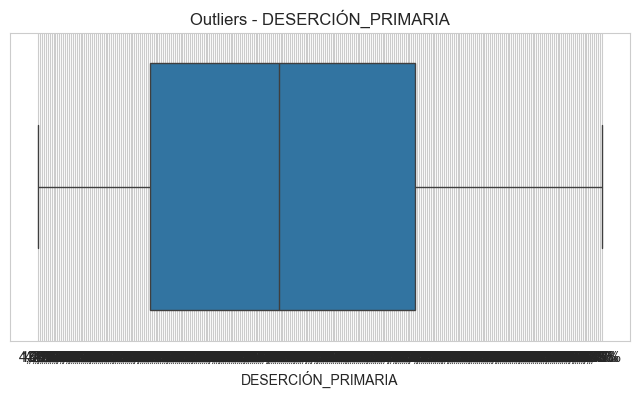

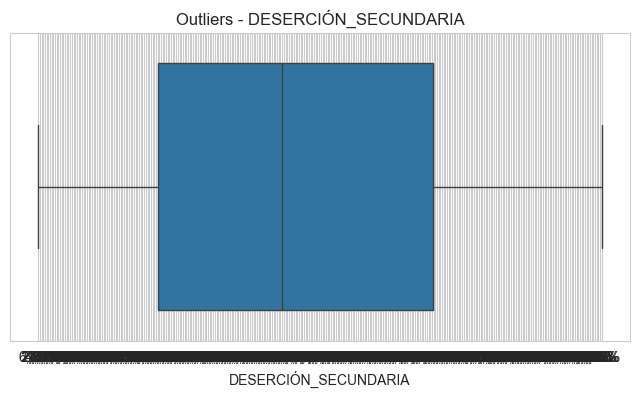

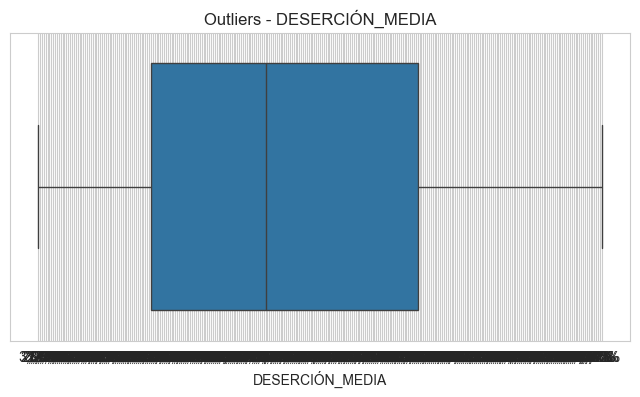

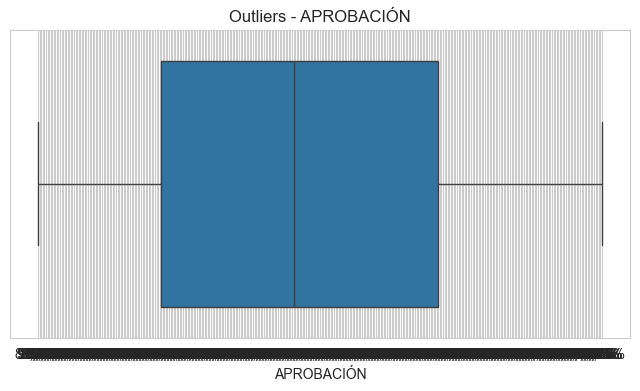

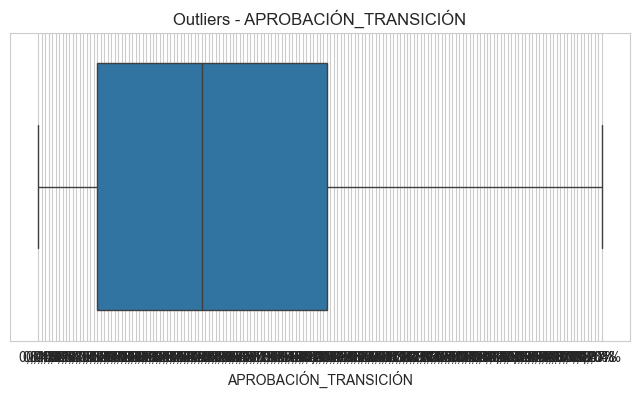

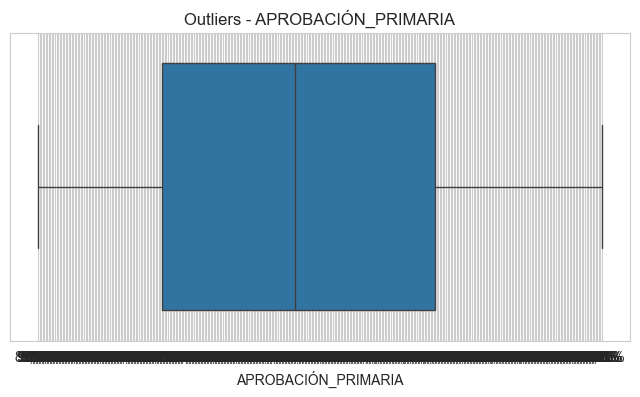

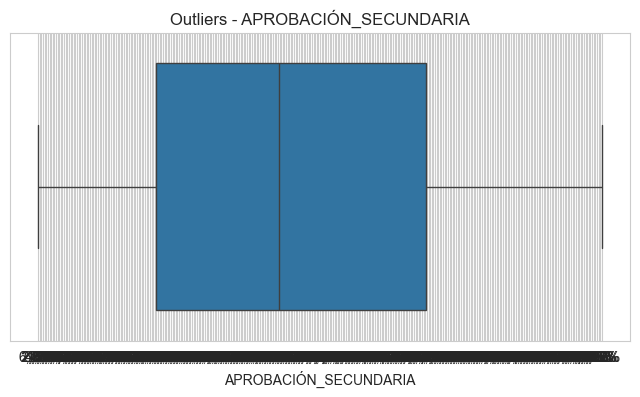

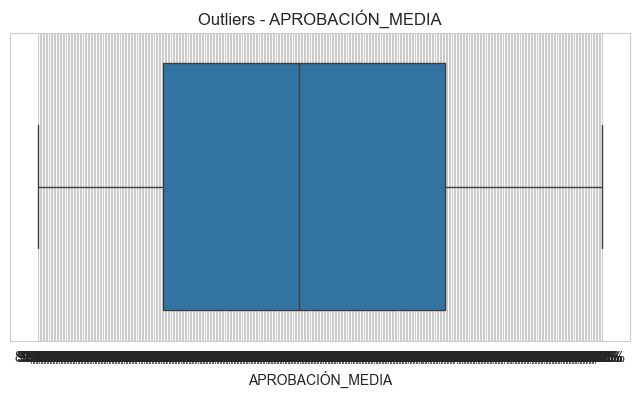

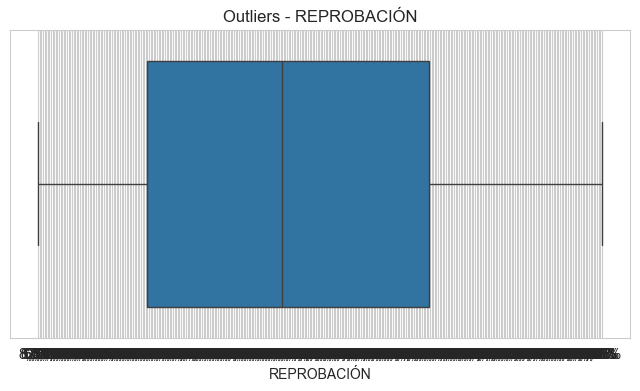

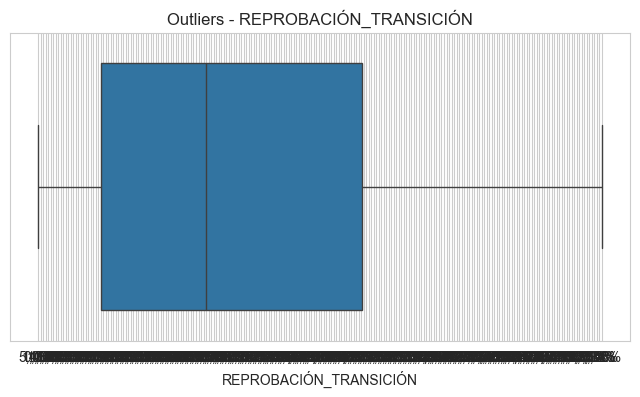

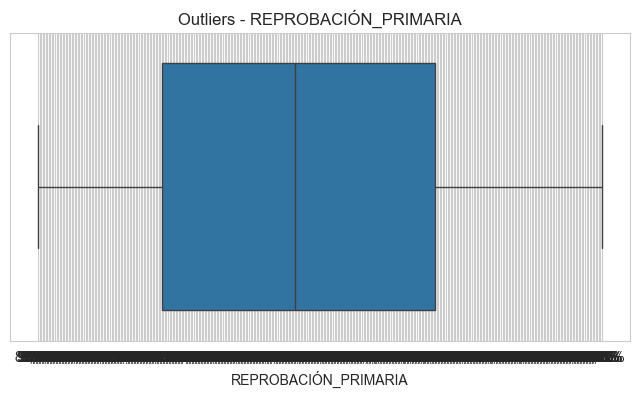

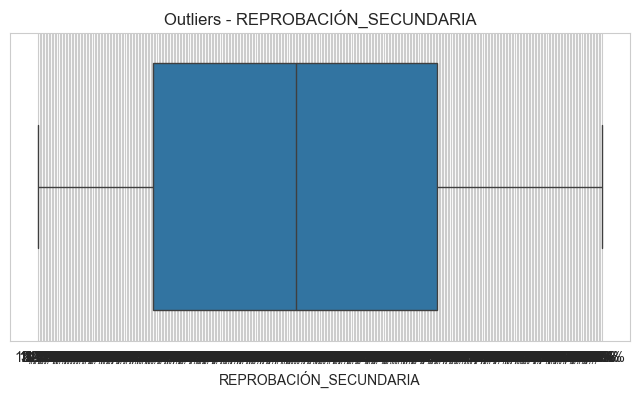

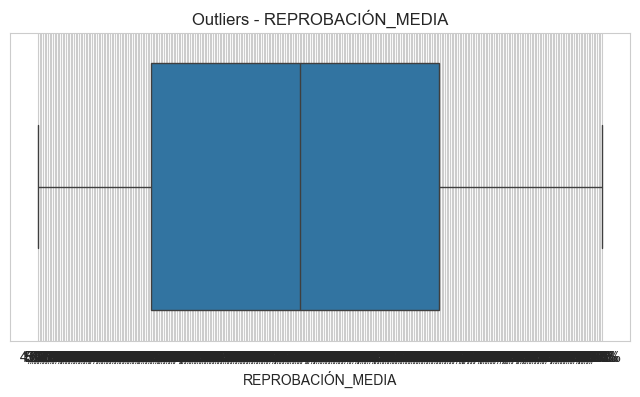

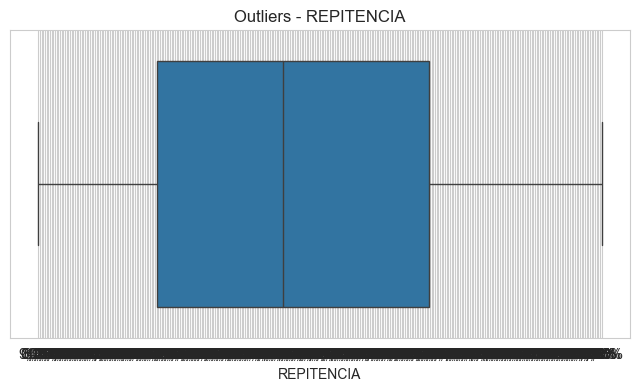

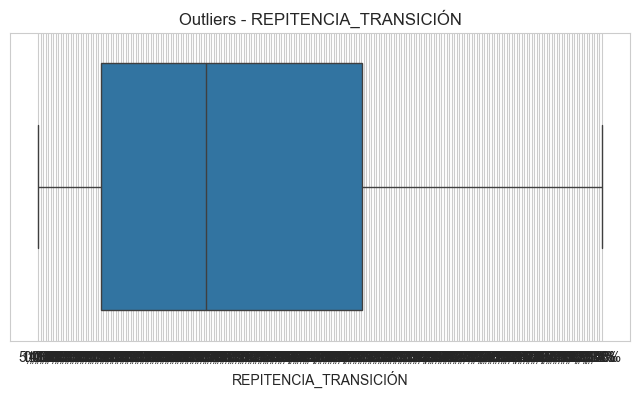

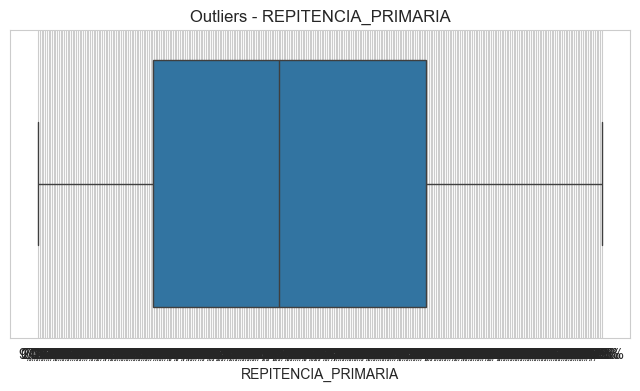

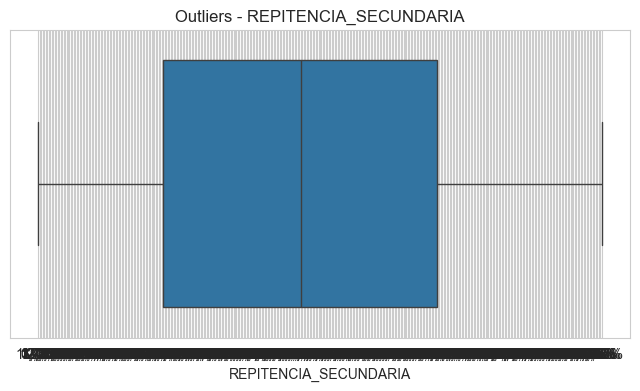

In [10]:
for columna in df_clean.columns[:-1]:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df_clean[columna])

    plt.title(f"Outliers - {columna}")

    plt.show()

In [12]:
# Copia del dataframe
df_clean = df.copy()

# Limpiar columnas numéricas
for col in df_clean.columns:

    # Ignorar columna texto
    if col != "DEPARTAMENTO":

        df_clean[col] = (
            df_clean[col]
            .astype(str)
            .str.replace("%", "", regex=False)
            .str.replace(",", ".", regex=False)
            .str.strip()
        )

        df_clean[col] = pd.to_numeric(
            df_clean[col],
            errors="coerce"
        )

In [13]:
# Seleccionar solo columnas numéricas
df_numerico = df_clean.select_dtypes(include=["number"])

outliers = {}

for columna in df_numerico.columns:

    Q1 = df_numerico[columna].quantile(0.25)
    Q3 = df_numerico[columna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    cantidad = df_numerico[
        (df_numerico[columna] < limite_inferior) |
        (df_numerico[columna] > limite_superior)
    ].shape[0]

    outliers[columna] = cantidad

# Resultado final
resultado_outliers = pd.DataFrame.from_dict(
    outliers,
    orient="index",
    columns=["Cantidad Outliers"]
).sort_values(
    by="Cantidad Outliers",
    ascending=False
)

resultado_outliers

,Cantidad Outliers
REPITENCIA_TRANSICIÓN,59
REPROBACIÓN_TRANSICIÓN,59
TAMAÑO_PROMEDIO_DE_GRUPO,57
POBLACIÓN_5_16,39
COBERTURA_BRUTA_SECUNDARIA,38
APROBACIÓN_TRANSICIÓN,37
COBERTURA_BRUTA_TRANSICIÓN,36
REPROBACIÓN_PRIMARIA,29
APROBACIÓN_PRIMARIA,29
DESERCIÓN_MEDIA,28


In [15]:
X = df_clean.drop(
    ["DESERCIÓN", "DEPARTAMENTO"],
    axis=1
)

y = df_clean["DESERCIÓN"]

In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,AÑO,CÓDIGO_DEPARTAMENTO,POBLACIÓN_5_16,TASA_MATRICULACIÓN_5_16,COBERTURA_NETA,COBERTURA_NETA_TRANSICIÓN,COBERTURA_NETA_PRIMARIA,COBERTURA_NETA_SECUNDARIA,COBERTURA_NETA_MEDIA,COBERTURA_BRUTA,...,REPROBACIÓN,REPROBACIÓN_TRANSICIÓN,REPROBACIÓN_PRIMARIA,REPROBACIÓN_SECUNDARIA,REPROBACIÓN_MEDIA,REPITENCIA,REPITENCIA_TRANSICIÓN,REPITENCIA_PRIMARIA,REPITENCIA_SECUNDARIA,REPITENCIA_MEDIA
0,1.382094,0.781175,1.809101,-0.725808,-0.781889,0.076016,-0.969215,-0.125065,0.605323,-0.998251,...,0.710816,1.607014,-0.593849,1.001638,0.629890,1.448623,1.607014,1.248382,1.551711,1.025504
1,-1.321199,-0.827406,-0.492005,-0.445893,NaN,0.389226,-0.109462,-1.754927,-1.552289,0.140921,...,0.053819,0.006854,0.146162,NaN,-0.341576,-1.250927,0.006854,-1.072131,-1.305647,-1.213381
2,NaN,-0.006701,0.329702,-1.405184,-1.437144,-1.687987,-1.625717,-0.782845,-0.705080,-1.342905,...,-1.079499,-0.596414,1.319297,-1.088504,-1.171222,NaN,-0.596414,-0.475798,-0.432836,-0.510874
3,1.627848,0.354409,-0.700648,0.441475,0.394084,0.944381,0.428138,0.740924,1.265671,-0.027778,...,0.253656,0.066753,-0.099783,0.651868,0.137066,1.132974,0.066753,0.706496,1.588281,1.488131
4,1.382094,-0.893062,1.001318,0.780676,0.710581,0.454331,0.446431,1.119545,1.412943,0.331387,...,0.212593,1.136379,0.248458,0.603112,0.062611,1.211135,1.136379,0.750573,1.624852,0.768489


In [17]:
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
AÑO,452.0,6.901068e-15,1.001108,-1.566953,-0.829691,-0.092430,0.890586,1.627848
CÓDIGO_DEPARTAMENTO,485.0,-9.522738e-17,1.001033,-1.549626,-1.057203,-0.006701,0.945316,1.536224
POBLACIÓN_5_16,452.0,-6.091489e-17,1.001108,-0.937176,-0.686131,-0.199760,0.129751,3.909918
TASA_MATRICULACIÓN_5_16,485.0,7.325183e-18,1.001033,-3.229487,-0.537254,0.179055,0.768041,1.786619
COBERTURA_NETA,456.0,6.466562e-16,1.001098,-3.405811,-0.514513,0.236320,0.729212,1.732661
COBERTURA_NETA_TRANSICIÓN,456.0,2.415222e-16,1.001098,-3.389524,-0.551283,0.107689,0.742466,2.267603
COBERTURA_NETA_PRIMARIA,456.0,-1.838685e-15,1.001098,-3.373678,-0.562966,0.220314,0.719042,1.874272
COBERTURA_NETA_SECUNDARIA,485.0,6.226405e-17,1.001033,-2.937870,-0.489761,0.289363,0.683236,1.506787
COBERTURA_NETA_MEDIA,485.0,-4.395110e-16,1.001033,-2.526975,-0.651238,0.197554,0.738343,2.107338
COBERTURA_BRUTA,456.0,1.213454e-15,1.001098,-3.473411,-0.433427,0.191258,0.657448,2.263263


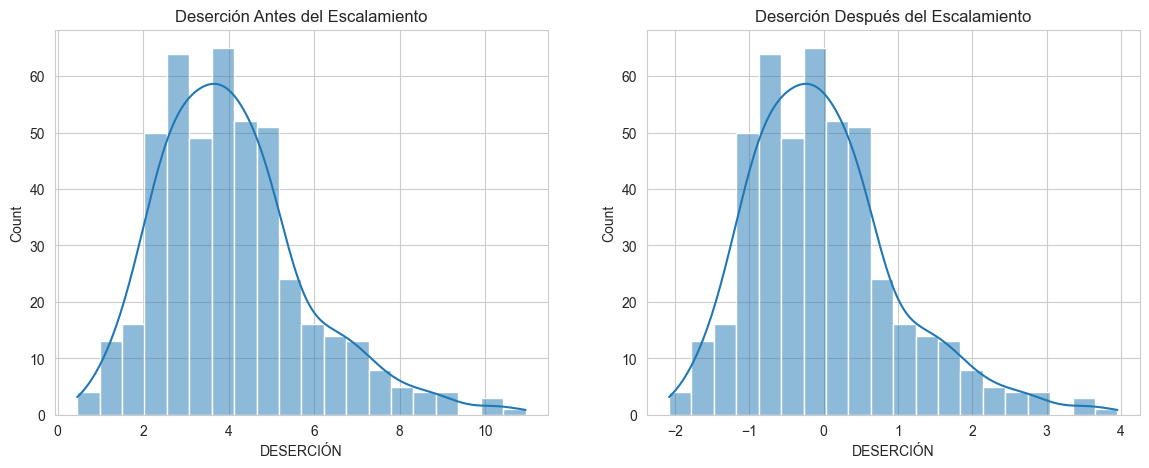

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Escalar DESERCIÓN
scaler = StandardScaler()

desercion_scaled = scaler.fit_transform(
    df_clean[["DESERCIÓN"]]
)

# Convertir a DataFrame
desercion_scaled = pd.DataFrame(
    desercion_scaled,
    columns=["DESERCIÓN"]
)

# Crear gráficos
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Antes del escalamiento
sns.histplot(
    df_clean["DESERCIÓN"],
    kde=True,
    ax=ax[0]
)

ax[0].set_title("Deserción Antes del Escalamiento")

# Después del escalamiento
sns.histplot(
    desercion_scaled["DESERCIÓN"],
    kde=True,
    ax=ax[1]
)

ax[1].set_title("Deserción Después del Escalamiento")

plt.show()

In [19]:
df_clean.to_csv(
    "../data/processed/datasetmodificado_clean.csv",
    index=False
)

print("Dataset limpio guardado")

Dataset limpio guardado


In [21]:
import numpy as np

# Seleccionar columnas numéricas
df_numerico = df_clean.select_dtypes(include=["number"])

# Verificar infinitos
np.isinf(df_numerico).sum()

AÑO                            0
CÓDIGO_DEPARTAMENTO            0
POBLACIÓN_5_16                 0
TASA_MATRICULACIÓN_5_16        0
COBERTURA_NETA                 0
COBERTURA_NETA_TRANSICIÓN      0
COBERTURA_NETA_PRIMARIA        0
COBERTURA_NETA_SECUNDARIA      0
COBERTURA_NETA_MEDIA           0
COBERTURA_BRUTA                0
COBERTURA_BRUTA_TRANSICIÓN     0
COBERTURA_BRUTA_PRIMARIA       0
COBERTURA_BRUTA_SECUNDARIA     0
COBERTURA_BRUTA_MEDIA          0
TAMAÑO_PROMEDIO_DE_GRUPO       0
SEDES_CONECTADAS_A_INTERNET    0
DESERCIÓN                      0
DESERCIÓN_TRANSICIÓN           0
DESERCIÓN_PRIMARIA             0
DESERCIÓN_SECUNDARIA           0
DESERCIÓN_MEDIA                0
APROBACIÓN                     0
APROBACIÓN_TRANSICIÓN          0
APROBACIÓN_PRIMARIA            0
APROBACIÓN_SECUNDARIA          0
APROBACIÓN_MEDIA               0
REPROBACIÓN                    0
REPROBACIÓN_TRANSICIÓN         0
REPROBACIÓN_PRIMARIA           0
REPROBACIÓN_SECUNDARIA         0
REPROBACIÓ

In [22]:
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)

In [23]:
df_clean.isnull().sum()

AÑO                             33
CÓDIGO_DEPARTAMENTO              0
DEPARTAMENTO                    19
POBLACIÓN_5_16                  33
TASA_MATRICULACIÓN_5_16          0
COBERTURA_NETA                  29
COBERTURA_NETA_TRANSICIÓN       29
COBERTURA_NETA_PRIMARIA         29
COBERTURA_NETA_SECUNDARIA        0
COBERTURA_NETA_MEDIA             0
COBERTURA_BRUTA                 29
COBERTURA_BRUTA_TRANSICIÓN      29
COBERTURA_BRUTA_PRIMARIA        29
COBERTURA_BRUTA_SECUNDARIA       0
COBERTURA_BRUTA_MEDIA           36
TAMAÑO_PROMEDIO_DE_GRUPO       240
SEDES_CONECTADAS_A_INTERNET    256
DESERCIÓN                       29
DESERCIÓN_TRANSICIÓN             1
DESERCIÓN_PRIMARIA               0
DESERCIÓN_SECUNDARIA            37
DESERCIÓN_MEDIA                  0
APROBACIÓN                       8
APROBACIÓN_TRANSICIÓN           29
APROBACIÓN_PRIMARIA              0
APROBACIÓN_SECUNDARIA            0
APROBACIÓN_MEDIA                 8
REPROBACIÓN                     29
REPROBACIÓN_TRANSICI

In [24]:
df_clean = df_clean.dropna()

print("Valores nulos eliminados")

Valores nulos eliminados


In [25]:
print(df_clean.isnull().sum().sum())

0


In [26]:
def eliminar_outliers_iqr(df, columnas):

    df_out = df.copy()

    for col in columnas:

        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)

        IQR = Q3 - Q1

        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        df_out = df_out[
            (df_out[col] >= limite_inferior) &
            (df_out[col] <= limite_superior)
        ]

    return df_out

In [29]:
# Seleccionar solo columnas numéricas
columnas_numericas = df_clean.select_dtypes(
    include=["number"]
).columns

# Eliminar outliers
df_clean = eliminar_outliers_iqr(
    df_clean,
    columnas_numericas
)

# Ver tamaño final
print(df_clean.shape)

(31, 37)


In [30]:
df_clean.to_csv(
    "../data/processed/datasetmodificado_clean.csv",
    index=False
)

print("Dataset limpio guardado")

Dataset limpio guardado
